<a href="https://colab.research.google.com/github/KAMAL0657/KAMAL-HUSSAIN/blob/main/AI_Traffic_Congestion_Capstone_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# AI Based Traffic Congestion & Incident Detection
## Capstone Project By KAMAL HUSSAIN

**Objective:**  
To detect traffic congestion and incidents using machine learning on aerial traffic feature data.

---


In [43]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Settings
plt.rcParams['figure.figsize'] = (8,5)



## Step 1: Load Dataset


In [44]:
import pandas as pd

# Load dataset
traffic_data_df = pd.read_excel('/content/Traffic Congestion.xlsx')
traffic_data_df.head()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1


In [45]:

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       440
           1       0.85      0.79      0.82       360

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



## Step 2: Data Understanding

In [46]:
traffic_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_density    4000 non-null   float64
 1   avg_vehicle_speed  4000 non-null   float64
 2   speed_std          4000 non-null   float64
 3   lane_occupancy     4000 non-null   float64
 4   queue_length       4000 non-null   float64
 5   edge_density       4000 non-null   float64
 6   optical_flow_mag   4000 non-null   float64
 7   shadow_fraction    4000 non-null   float64
 8   time_of_day_norm   4000 non-null   float64
 9   road_width_norm    4000 non-null   float64
 10  label              4000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.9 KB


Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [47]:
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
parking_data_dict = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
parking_df = pd.DataFrame(parking_data_dict)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(parking_df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Expired Meter,50283
1,NJ,Double Parking,50525
2,NY,No Parking,50118
3,TX,Bus Stop,50553


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## Step 2: Data Understanding


In [49]:
traffic_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_density    4000 non-null   float64
 1   avg_vehicle_speed  4000 non-null   float64
 2   speed_std          4000 non-null   float64
 3   lane_occupancy     4000 non-null   float64
 4   queue_length       4000 non-null   float64
 5   edge_density       4000 non-null   float64
 6   optical_flow_mag   4000 non-null   float64
 7   shadow_fraction    4000 non-null   float64
 8   time_of_day_norm   4000 non-null   float64
 9   road_width_norm    4000 non-null   float64
 10  label              4000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.9 KB



## Step 3: Data Preprocessing


In [50]:

# Drop missing values if any
traffic_data_df = traffic_data_df.dropna()

# Assume last column is target label
X = traffic_data_df.iloc[:, :-1]
y = traffic_data_df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



## Step 4: Exploratory Data Analysis (EDA)


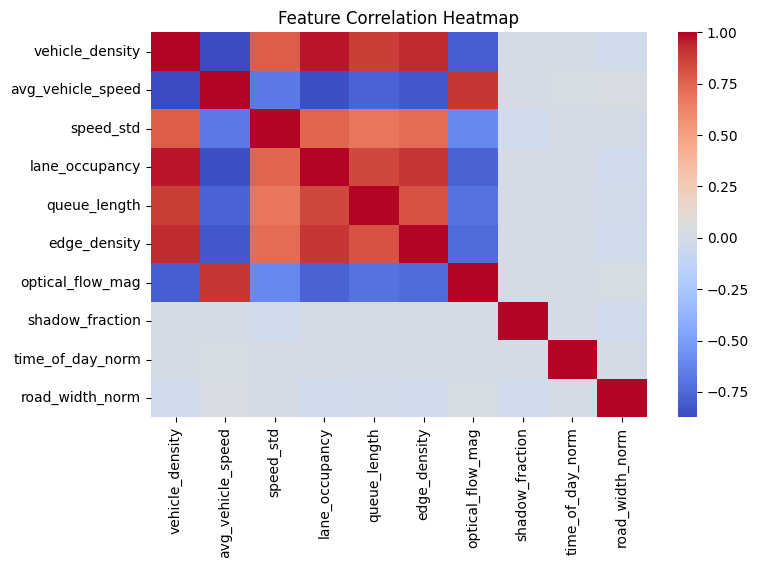

In [51]:

# Correlation heatmap
sns.heatmap(traffic_data_df.drop('label', axis=1).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



## Step 5: Model Training
### Logistic Regression


In [52]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       440
           1       0.85      0.81      0.83       360

    accuracy                           0.85       800
   macro avg       0.85      0.84      0.85       800
weighted avg       0.85      0.85      0.85       800




### Random Forest Classifier


In [53]:

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       440
           1       0.85      0.79      0.82       360

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800




## Step 6: Model Evaluation


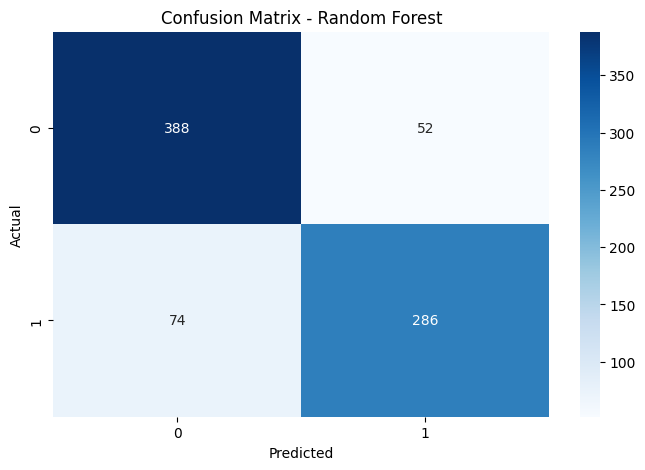

ROC-AUC Score: 0.9260511363636363


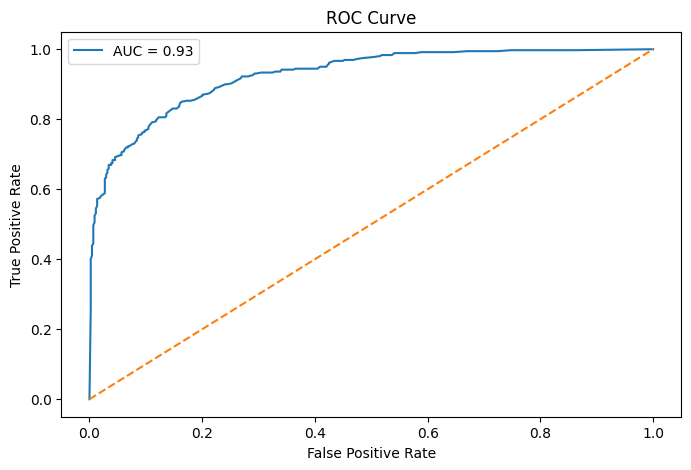

In [54]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC
y_prob = rf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



## Step 7: Traffic Congestion Heatmap (Conceptual)


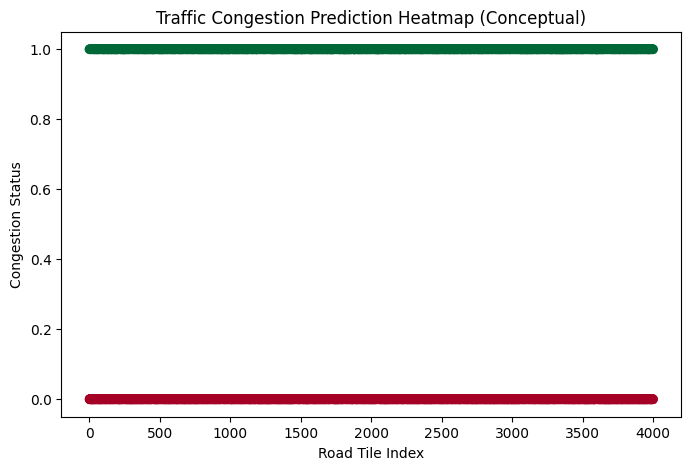

In [55]:

# Add predictions to dataset
traffic_data_df['Prediction'] = rf.predict(scaler.transform(traffic_data_df.iloc[:, :-1]))

# Simple congestion visualization
plt.scatter(range(len(traffic_data_df)), traffic_data_df['Prediction'], c=traffic_data_df['Prediction'], cmap='RdYlGn')
plt.title("Traffic Congestion Prediction Heatmap (Conceptual)")
plt.xlabel("Road Tile Index")
plt.ylabel("Congestion Status")
plt.show()



## Conclusion

- Successfully detected traffic congestion using ML.
- Random Forest performed better than Logistic Regression.
- This system can help traffic authorities in smart traffic management.

## Future Scope
- Real-time video integration
- Deep learning models (CNN)
- Live traffic alert systems
